# Project: Investigate a Dataset - Investigating Factors Associated with Missed Medical Appointments

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

<a id='intro'></a>
## Introduction

### Dataset Description 



This dataset contains information about more than 100,000 medical appointments in Brazil. The dataset focuses on whether patients attended their scheduled appointments and includes demographic, medical, and appointment-related information. The main outcome variable is "No-show", which indicates whether a patient missed their appointment.

The analysis focuses on identifying associations between patient characteristics and appointment attendance rather than establishing causation.


### Question(s) for Analysis


### Primary Research Question

What factors are associated with missed medical appointments?

### Supporting Questions

1. Does age appear to be associated with appointment attendance?
2. Is there a relationship between receiving an SMS reminder and appointment attendance?
3. Does waiting time between scheduling and appointment dates relate to missed appointments?
4. Is scholarship status associated with appointment attendance?

In [38]:
# Use this cell to set up import statements for all of the packages that you
#   plan to use.

# While optional for current notebooks, if you are having trouble with visualizations,
#   remember to include a 'magic word' so that your visualizations are plotted
#   inline with the notebook. See this page for more:
#   http://ipython.readthedocs.io/en/stable/interactive/magics.html

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [39]:
# Function to add titles and axis labels to plots
def pltfunc(title , xlabel, ylabel):
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

<a id='wrangling'></a>
## Data Wrangling




### General Properties


In [40]:
# Load your data and print out a few lines. What is the size of your dataframe? 
#   Perform operations to inspect data types and look for instances of missing
#   or possibly errant data. There are at least 4 - 6 methods you can call on your
#   dataframe to obtain this information.

#load the data
df = pd.read_csv('Database_No_show_appointments/noshowappointments-kagglev2-may-2016.csv')

In [41]:
df.shape

(110527, 14)

The dataset contains 110,527 records and 14 columns.

In [42]:
#display first 5 rows
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [43]:
#see datatypes and if there is nullvalues
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


No missing values were found, the date columns are currently stored as object data types and will require conversion to datetime format during the cleaning phase.

In [44]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


the Age column contains at least one invalid value (-1).

In [45]:
df.duplicated().sum()

0

No duplicate records were found in the dataset.

In [46]:
#number of minus age 
(df['Age'] < 0).sum()

1

One record with an invalid age value was identified.

### Assessment Summary

The dataset contains 110,527 records and 14 columns. No missing values or duplicate records were found. One invalid age value (-1) was identified in the Age column. In addition, the ScheduledDay and AppointmentDay columns are stored as object data types and require conversion to datetime format before analysis.


### Data Cleaning


#### Removing Invalid Age Values

One record contained an invalid age value (-1). Since the correct age is unknown and the record represents a very small portion of the dataset, it was removed.

In [47]:
# One record with an invalid age value (-1) was identified.
# Only valid ages (Age >= 0) were retained for further analysis.

df = df[df['Age'] >= 0]

In [48]:
# Verify that no invalid age values remain
(df['Age'] < 0).sum()

0

The validation check confirms that no invalid age values remain in the dataset.

#### Converting Date Columns

The ScheduledDay and AppointmentDay columns were stored as object data types. They were converted to datetime format to enable date-based calculations and analysis.

In [49]:
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 110526 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   PatientId       110526 non-null  float64            
 1   AppointmentID   110526 non-null  int64              
 2   Gender          110526 non-null  object             
 3   ScheduledDay    110526 non-null  datetime64[ns, UTC]
 4   AppointmentDay  110526 non-null  datetime64[ns, UTC]
 5   Age             110526 non-null  int64              
 6   Neighbourhood   110526 non-null  object             
 7   Scholarship     110526 non-null  int64              
 8   Hipertension    110526 non-null  int64              
 9   Diabetes        110526 non-null  int64              
 10  Alcoholism      110526 non-null  int64              
 11  Handcap         110526 non-null  int64              
 12  SMS_received    110526 non-null  int64              
 13  No-show       

The verification confirms that both date columns were successfully converted to datetime format and are now ready for date-based calculations.

#### Creating Waiting Days Variable

A new variable called waiting_days was created to measure the number of days between scheduling an appointment and the actual appointment date.

In [51]:
df['waiting_days'] = df['AppointmentDay'].dt.date - df['ScheduledDay'].dt.date

In [52]:
df['waiting_days'] = df['waiting_days'].dt.days

In [53]:
df['waiting_days'].head()

0    0
1    0
2    0
3    0
4    0
Name: waiting_days, dtype: int64

In [54]:
# Check the distribution of waiting_days and identify potential invalid values
df['waiting_days'].describe()

count    110526.000000
mean         10.183794
std          15.255034
min          -6.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: waiting_days, dtype: float64

The minimum waiting time is -6 days, indicating that some appointments were scheduled after their appointment date and require further investigation.

In [55]:
(df['waiting_days'] < 0).sum()

5

In [56]:
df[df['waiting_days'] < 0]

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,waiting_days
27033,7.839273e+12,5679978,M,2016-05-10 10:51:53+00:00,2016-05-09 00:00:00+00:00,38,RESISTÊNCIA,0,0,0,0,1,0,Yes,-1
55226,7.896294e+12,5715660,F,2016-05-18 14:50:41+00:00,2016-05-17 00:00:00+00:00,19,SANTO ANTÔNIO,0,0,0,0,1,0,Yes,-1
64175,2.425226e+13,5664962,F,2016-05-05 13:43:58+00:00,2016-05-04 00:00:00+00:00,22,CONSOLAÇÃO,0,0,0,0,0,0,Yes,-1
71533,9.982316e+14,5686628,F,2016-05-11 13:49:20+00:00,2016-05-05 00:00:00+00:00,81,SANTO ANTÔNIO,0,0,0,0,0,0,Yes,-6
72362,3.787482e+12,5655637,M,2016-05-04 06:50:57+00:00,2016-05-03 00:00:00+00:00,7,TABUAZEIRO,0,0,0,0,0,0,Yes,-1


#### Handling Negative Waiting Times

Five records were found with negative waiting times, indicating that the appointment date occurred before the scheduling date. Since these records contain invalid temporal information, they were removed from the dataset.

In [57]:
df = df[df['waiting_days'] >= 0] 

All records with negative waiting times were removed from the dataset.

In [58]:
(df['waiting_days'] < 0).sum()

0

The validation confirms that all records with negative waiting times were removed successfully.

### Cleaning Summary

Several data quality issues were addressed before the analysis phase. One record with an invalid age value (-1) was removed. The ScheduledDay and AppointmentDay columns were converted from object to datetime format. A new variable called waiting_days was created to measure the time between scheduling and appointment dates. Finally, five records with negative waiting times were removed because they contained inconsistent date information. The cleaned dataset is now ready for exploratory analysis.

<a id='eda'></a>
## Exploratory Data Analysis


In this section, the relationship between patient age and appointment attendance will be explored. Both summary statistics and visualizations will be used to determine whether age appears to influence the likelihood of missing a medical appointment.


### Research Question 1:
Does age appear to be associated with appointment attendance?

In [59]:
# Use this, and more code cells, to explore your data. Don't forget to add
#   Markdown cells to document your observations and findings.
df['Age'].describe()

count    110521.000000
mean         37.089386
std          23.109885
min           0.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: Age, dtype: float64

The dataset contains 110,521 valid patient records. The average patient age is approximately 37 years, which is also close to the median age of 37 years. Half of the patients are aged 37 years or younger, while 75% are aged 55 years or younger. Patient ages range from 0 to 115 years.

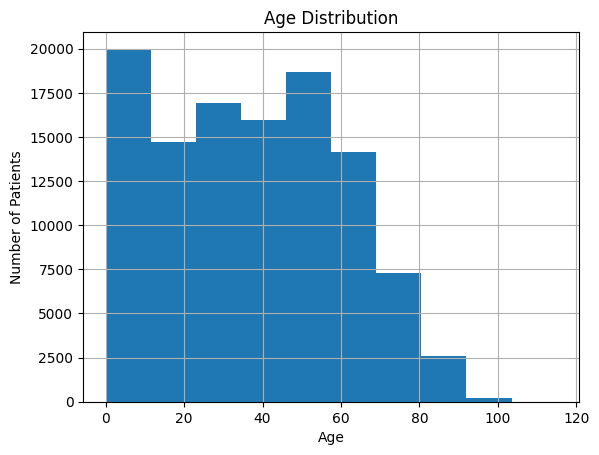

In [60]:
df['Age'].hist()
pltfunc(
    'Age Distribution',
    'Age',
    'Number of Patients'
)

### Observation

The age distribution shows that most patients are younger than 70 years old. The number of patients gradually decreases at older ages, especially after age 70. Very few patients are older than 90 years, indicating that elderly patients represent a small portion of the dataset.

In [61]:
df.groupby('No-show')['Age'].describe()

,count,mean,std,min,25%,50%,75%,max
No-show,,,,,,,,
No,88207.0,37.790504,23.338645,0.0,18.0,38.0,56.0,115.0
Yes,22314.0,34.317872,21.965009,0.0,16.0,33.0,51.0,115.0


Patients who attended their appointments were slightly older on average than those who missed them. The mean age of attendees was approximately 37.8 years, compared with 34.3 years for non-attendees. Although a difference exists, it is relatively small, suggesting that age alone may not be a strong predictor of appointment attendance.

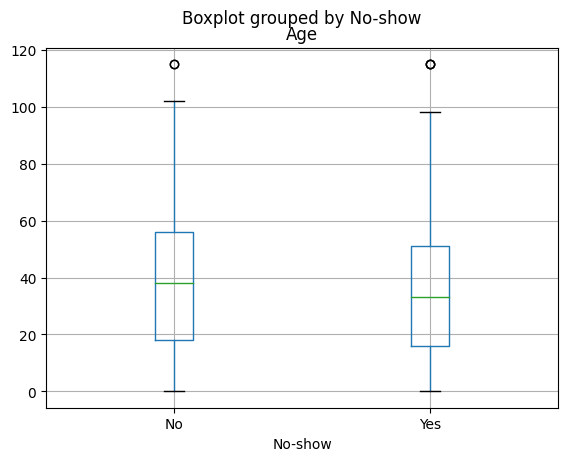

In [62]:
df.boxplot(column='Age', by='No-show');

### Observation

The boxplots show that patients who attended their appointments were slightly older on average (37.8 years) than those who missed them (34.3 years). However, the distributions are highly similar and overlap considerably, suggesting that age may have only a weak association with appointment attendance and is unlikely to be a strong determining factor on its own.


## Research Question 2

Does receiving an SMS reminder appear to be associated with appointment attendance?

In this section, the relationship between SMS reminders and appointment attendance will be explored. Summary statistics were used to examine whether receiving an SMS reminder appears to be associated with missing or attending appointments.

In [63]:
# Continue to explore the data to address your additional research
#   questions. Add more headers as needed if you have more questions to
#   investigate.
df.groupby('SMS_received')['No-show'].value_counts()

SMS_received  No-show
0             No         62509
              Yes        12530
1             No         25698
              Yes         9784
Name: No-show, dtype: int64

In [64]:
df.groupby('SMS_received')['No-show'].value_counts(normalize=True)

SMS_received  No-show
0             No         0.833020
              Yes        0.166980
1             No         0.724255
              Yes        0.275745
Name: No-show, dtype: float64

### Observation

Patients who received an SMS reminder had a higher proportion of missed appointments (27.6%) compared to patients who did not receive an SMS reminder (16.7%). This indicates that receiving an SMS reminder appears to be associated with a higher rate of missed appointments. However, this result should not be interpreted as a causal relationship, as other factors not included in the analysis may influence appointment attendance.


## Research Question 3

Does waiting time between scheduling and appointment dates relate to missed appointments?

In [65]:
df.groupby('No-show')['waiting_days'].describe()

,count,mean,std,min,25%,50%,75%,max
No-show,,,,,,,,
No,88207.0,8.754759,14.55045,0.0,0.0,2.0,12.0,179.0
Yes,22314.0,15.835484,16.60560,0.0,4.0,11.0,23.0,179.0


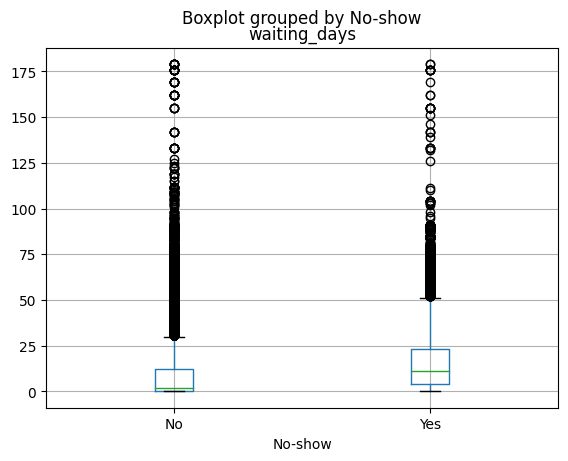

In [66]:
df.boxplot(column='waiting_days', by='No-show');

### Observation

The boxplots show that patients who missed their appointments generally had longer waiting times than those who attended. The median waiting time was 11 days for missed appointments compared to only 2 days for attended appointments. Although the distributions overlap, the higher median and overall distribution for the missed-appointment group suggest that longer waiting times may be associated with a greater likelihood of missing an appointment.

## Research Question 4

Is scholarship status associated with appointment attendance?

In [67]:
df.groupby('Scholarship')['No-show'].value_counts()

Scholarship  No-show
0            No         79924
             Yes        19736
1            No          8283
             Yes         2578
Name: No-show, dtype: int64

In [68]:
df.groupby('Scholarship')['No-show'].value_counts(normalize=True)

Scholarship  No-show
0            No         0.801967
             Yes        0.198033
1            No         0.762637
             Yes        0.237363
Name: No-show, dtype: float64

### Observation

Patients who received a scholarship had a slightly higher proportion of missed appointments (23.7%) compared to patients who did not receive a scholarship (19.8%). This suggests that scholarship status may have a weak association with appointment attendance. However, the difference is relatively small, indicating that scholarship status alone is unlikely to be a strong predictor of missed appointments.

<a id='conclusions'></a>
## Conclusions

This analysis explored several factors that may be associated with appointment attendance.

Age appeared to have only a weak association with attendance. Patients who attended their appointments were slightly older on average than those who missed them, but the age distributions were highly similar.

Patients who received an SMS reminder had a higher proportion of missed appointments (27.6%) compared to those who did not receive an SMS reminder (16.7%). This suggests a possible association between SMS reminders and appointment attendance, although no causal relationship can be inferred.

Waiting time showed the strongest association with appointment attendance. Patients who missed their appointments generally waited longer between scheduling and the appointment date. The median waiting time was 11 days for missed appointments compared to 2 days for attended appointments.

Scholarship recipients had a slightly higher proportion of missed appointments (23.7%) than non-recipients (19.8%). However, the difference was relatively small, suggesting only a weak association.

Overall, waiting time appeared to be the factor most strongly associated with missed appointments among the variables examined in this analysis.

## Limitations

This analysis was based on exploratory data analysis and did not include statistical hypothesis testing. Therefore, the findings should be interpreted as associations rather than causal relationships.

In addition, the dataset does not include potentially important factors such as income level, transportation availability, employment status, or reasons for missing appointments. These factors may influence appointment attendance and could provide additional insight in future studies.


## Submitting your Project 


In [69]:
# Running this cell will execute a bash command to convert this notebook to an .html file
!python -m nbconvert --to html Investigate_a_Dataset.ipynb

[NbConvertApp] Converting notebook Investigate_a_Dataset.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 427880 bytes to Investigate_a_Dataset.html
